# Analiza najbolje ocenjenih albumov (AlbumOfTheYear)

Projektna naloga se osredotoča na podatke o 1000 najbolje ocenjenih albumih vseh časov, pridobljene s strani [AlbumOfTheYear](https://www.albumoftheyear.org/ratings/6-highest-rated/all/1). Za vsak album poznamo izvajalca, naslov, datum izida, žanre, oceno kritika (0-100), število recenzij in platforme, na katerih je album na voljo. Za analizo sem izbral prvih 1000 od skupno približno 5000 albumov na lestvici. Opazil sem, da vrstni red albumov ni strogo urejen po prikazani oceni - AOTY najverjetneje uporablja neko uteženo formulo, ki poleg ocene upošteva tudi število recenzij, saj albumi z zelo malo recenzijami občasno dosežejo najvišje ocene, a niso nujno uvrščeni na sam vrh. Menim, da bi razširitev vzorca na vseh ~5000 albumov le malo spremenila glavne ugotovitve te analize, saj gre proti dnu lestvice za albume z manj soglasja kritikov, torej bi dodajali predvsem šum, medtem ko so najbolj priznani albumi (in s tem tudi prevladujoča desetletja, žanri in izvajalci) že zajeti v prvih 500.

## 1. Nalaganje in priprava podatkov

Podatke naložimo enkrat na začetku in tu tudi izvedemo vse pretvorbe tipov (ocena, datum, žanri, platforme, desetletje), da so v vseh nadaljnjih celicah že pripravljeni za uporabo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('podatki/albumi.csv')

df['ocena'] = pd.to_numeric(df['ocena'], errors='coerce')
df['st_recenzij'] = pd.to_numeric(df['st_recenzij'], errors='coerce')
df['leto'] = pd.to_numeric(df['leto'], errors='coerce')
df['mesec'] = pd.to_numeric(df['mesec'], errors='coerce')
df['datum_izida'] = pd.to_datetime(df['datum_izida'], errors='coerce')

pred = len(df)
df = df.dropna(subset=['ocena', 'leto']).copy()
df['leto'] = df['leto'].astype(int)
print(f'Odstranjenih vrstic zaradi manjkajočih podatkov: {pred - len(df)}')

df['zanri_seznam'] = df['zanri'].fillna('').apply(
    lambda s: [z.strip() for z in s.split(',') if z.strip()]
)
df['platforme_seznam'] = df['platforme'].fillna('').apply(
    lambda s: [p.strip() for p in s.split(',') if p.strip()]
)

df['desetletje'] = (df['leto'] // 10) * 10

IMENA_STOLPCEV = {
    'izvajalec': 'Izvajalec',
    'naslov': 'Naslov',
    'datum_izida': 'Datum izida',
    'leto': 'Leto',
    'mesec': 'Mesec',
    'zanri': 'Žanri',
    'ocena': 'Ocena',
    'st_recenzij': 'Št. recenzij',
    'platforme': 'Platforme',
    'desetletje': 'Desetletje',
}
PRIKAZNI_STOLPCI = ['izvajalec', 'naslov', 'datum_izida', 'leto', 'mesec',
                     'zanri', 'ocena', 'st_recenzij', 'platforme', 'desetletje']

print(f'Skupaj albumov: {len(df)}')
df[PRIKAZNI_STOLPCI].rename(columns=IMENA_STOLPCEV).head(10)

Odstranjenih vrstic zaradi manjkajočih podatkov: 0
Skupaj albumov: 1000


,Izvajalec,Naslov,Datum izida,Leto,Mesec,Žanri,Ocena,Št. recenzij,Platforme,Desetletje
0,Kendrick Lamar,To Pimp a Butterfly,2015-03-15,2015,3.0,"Conscious Hip Hop, Jazz Rap, West Coast Hip Ho...",95,47,"Amazon, Amazon (Vinyl), Apple Music, SoundClou...",2010
1,The Beatles,Revolver,1966-08-05,1966,8.0,"Pop Rock, Psychedelic Pop, Psychedelic Rock, E...",100,9,"Amazon, Amazon (Vinyl), Apple Music, Spotify",1960
2,Prince,"Sign ""☮︎"" the Times",1987-03-31,1987,3.0,"Contemporary R&B, Synth Funk, Pop Rock, Minnea...",99,9,"Amazon, Apple Music, Spotify",1980
3,The Beatles,Abbey Road,1969-09-26,1969,9.0,"Pop Rock, Progressive Pop, Psychedelic Pop, Ar...",100,8,"Amazon, Amazon (Vinyl), Apple Music, Spotify",1960
4,Nick Cave and the Bad Seeds,Ghosteen,2019-10-04,2019,10.0,"Singer-Songwriter, Spoken Word, New Age, Ambient",93,37,"Amazon, Apple Music, Spotify",2010
5,The Beatles,Rubber Soul,1965-12-03,1965,12.0,"Pop Rock, Folk Rock, Psychedelic Pop, Folk Pop...",100,8,"Amazon, Amazon (Vinyl), Apple Music, Spotify",1960
6,Kendrick Lamar,DAMN.,2017-04-14,2017,4.0,"Conscious Hip Hop, West Coast Hip Hop, Pop Rap...",93,44,"Amazon, Amazon (Vinyl), Apple Music, SoundClou...",2010
7,Fiona Apple,Fetch the Bolt Cutters,2020-04-17,2020,4.0,"Art Pop, Singer-Songwriter, Progressive Pop, P...",93,35,"Amazon, Amazon (Vinyl), Apple Music, SoundClou...",2020
8,Eno,Another Green World,1975-11-14,1975,11.0,"Art Rock, Ambient, Electronic, Art Pop",99,8,"Amazon, Amazon (Vinyl), Apple Music, Spotify",1970
9,Public Enemy,It Takes a Nation of Millions to Hold Us Back,1988-06-28,1988,6.0,"Hardcore Hip Hop, East Coast Hip Hop, Consciou...",99,8,"Amazon, Apple Music, SoundCloud, Spotify",1980


## 2. Porazdelitev ocen
Najprej nas zanima kako so iz našega vzorca 1000 albumov porazdeljene njihove ocene.

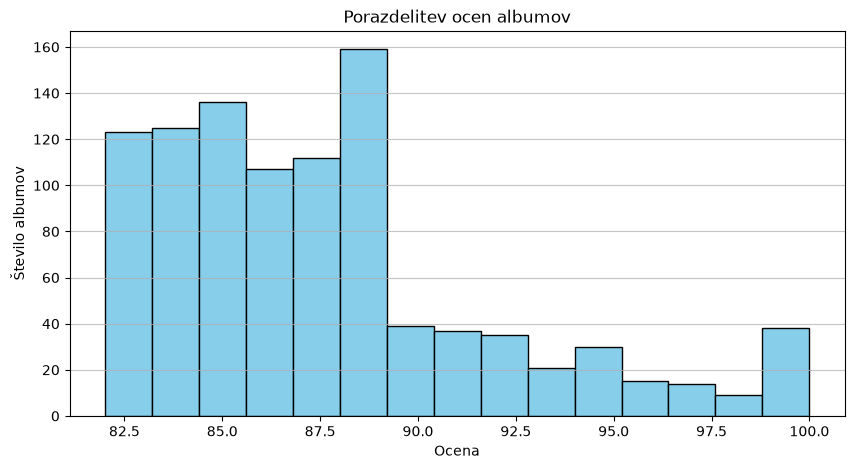

In [2]:
plt.figure(figsize=(10, 5))
plt.hist(df['ocena'], bins=15, color='skyblue', edgecolor='black')
plt.title('Porazdelitev ocen albumov')
plt.xlabel('Ocena')
plt.ylabel('Število albumov')
plt.grid(axis='y', alpha=0.75)
plt.show()

Ocene razdelimo tudi v razrede, da lažje vidimo deleže na tortnem diagramu:

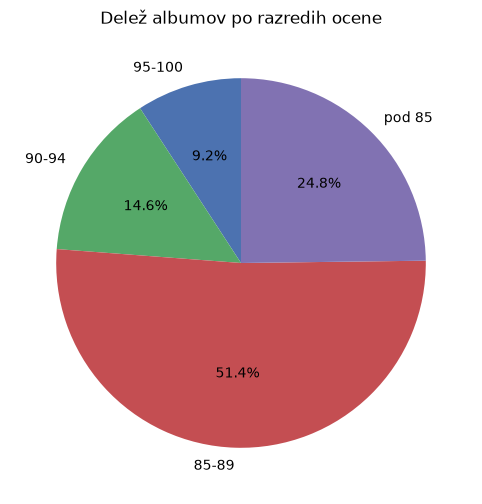

Povprečna ocena: 87.6, najnižja: 82
razred_ocene
95-100     92
90-94     146
85-89     514
pod 85    248
Name: count, dtype: int64


In [3]:
def razred_ocene(ocena):
    if ocena >= 95:
        return '95-100'
    elif ocena >= 90:
        return '90-94'
    elif ocena >= 85:
        return '85-89'
    else:
        return 'pod 85'

df['razred_ocene'] = df['ocena'].apply(razred_ocene)
vrstni_red = ['95-100', '90-94', '85-89', 'pod 85']
stevilo_po_razredu = df['razred_ocene'].value_counts().reindex(vrstni_red).fillna(0)

plt.figure(figsize=(6, 6))
plt.pie(stevilo_po_razredu, labels=stevilo_po_razredu.index, autopct='%1.1f%%',
        colors=['#4C72B0', '#55A868', '#C44E52', '#8172B2'], startangle=90)
plt.title('Delež albumov po razredih ocene')
plt.show()

print(f"Povprečna ocena: {df['ocena'].mean():.1f}, najnižja: {df['ocena'].min():.0f}")
print(stevilo_po_razredu)

Kakor vidimo, je porazdelitev ocen zgoščena tam pri 85 do 89-tih točkah, kjer leži 51,4% albumov, sledi razred  z oceno pod 85, in sicer 24,8% albumov, višje pri 90 do 94-tih(14,6% albumov), rekel bi da je to kar smiselno, saj govorimo o najboljših albumih vseh časov, da bi bili vsi pri visokih 90-tih točkah pa je težko pričakovati, saj so te rezervirane za res prave mojstrovine.

## 3. Top 10 albumov

In [4]:
top10 = df.sort_values(by='ocena', ascending=False).head(10)
display(top10[['izvajalec', 'naslov', 'leto', 'ocena', 'st_recenzij']]
        .rename(columns=IMENA_STOLPCEV))

,Izvajalec,Naslov,Leto,Ocena,Št. recenzij
31,Metallica,Master of Puppets,1986,100,6
30,The Smiths,The Queen Is Dead,1986,100,6
16,Paul Simon,Graceland,1986,100,7
35,Patti Smith,Horses,1975,100,6
34,Leonard Cohen,Songs of Leonard Cohen,1967,100,6
33,Miles Davis,Kind of Blue,1959,100,6
38,Television,Marquee Moon,1977,100,6
32,Bob Dylan,Blood on the Tracks,1975,100,6
66,The Velvet Underground & Nico,The Velvet Underground & Nico,1967,100,5
74,Big Star,3rd,1978,100,5


Iz vzorca desetih najvišje ocenjenih albumov je moč videti, da jih ima vseh 10 oceno 100, če smo pozorni lahko vidimo, da imajo vsi od 5 pa do 7 recenzij, torej najvišje ocenjeni albumi niso tisti z največ recenzijami.

## 4. Izvajalci z največ albumi na lestvici

In [5]:
stevilo_po_izvajalcu = df['izvajalec'].value_counts()
display(stevilo_po_izvajalcu.head(10).rename_axis('Izvajalec').rename('Število albumov'))

top_izvajalci = df.groupby('izvajalec').filter(lambda x: len(x) >= 2)
povprecne_ocene = top_izvajalci.groupby('izvajalec')['ocena'].mean().sort_values(ascending=False)
display(povprecne_ocene.head(10).rename_axis('Izvajalec').rename('Povprečna ocena'))

Izvajalec
The Beatles                  10
David Bowie                   9
Bob Dylan                     8
Bruce Springsteen             8
SAULT                         6
Kendrick Lamar                5
Led Zeppelin                  5
Nick Cave & The Bad Seeds     5
Leonard Cohen                 5
Tom Waits                     5
Name: Število albumov, dtype: int64

Izvajalec
Stevie Wonder      99.500000
Pixies             99.500000
Grateful Dead      99.000000
Michael Jackson    98.000000
Miles Davis        98.000000
Pink Floyd         96.666667
Joni Mitchell      96.333333
Metallica          96.000000
Prince             96.000000
U2                 96.000000
Name: Povprečna ocena, dtype: float64

Pri tem razdelku smo bili pozorni na to kateri umetniki imajo največ albumov na tej lestvici. Očitni zmagovalci so The Beatles z desetimi.
Sledila je analiza povprečne ocene albumov glede na izvajalca, kjer sta pa na samem vrhu Stevie Wonder in Pixies.

## 5. Albumi po desetletjih

Desetletje
1950      2
1960     25
1970     88
1980     51
1990    109
2000    128
2010    279
2020    318
Name: Število albumov, dtype: int64

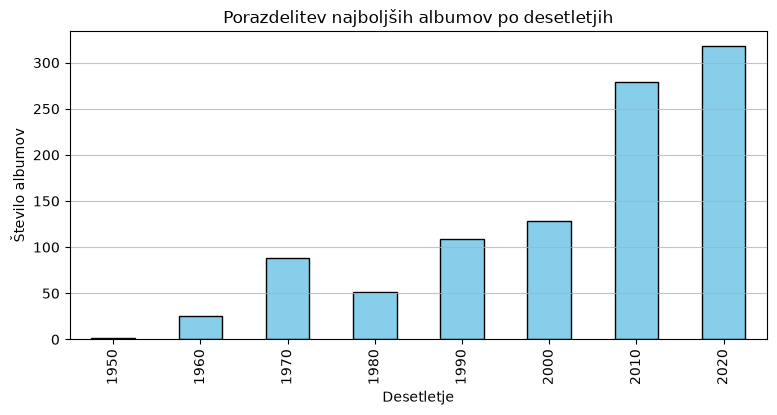

In [6]:
po_desetletju = df['desetletje'].value_counts().sort_index()
display(po_desetletju.rename_axis('Desetletje').rename('Število albumov'))

plt.figure(figsize=(9, 4))
po_desetletju.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Porazdelitev najboljših albumov po desetletjih')
plt.xlabel('Desetletje')
plt.ylabel('Število albumov')
plt.grid(axis='y', alpha=0.75)
plt.show()

Nato me je zanimalo, iz katerega obdobja na našem seznamu izvira največ albumov, oziroma kako je število albumov razdeljeno po desetletjih. Očitna je prevlada dvajsetih let trenutnega tisočletja in pa na splošno dva tisočih let. To je verjetno posledica tega, da je ustvarjanje glasbe v današnjem času veliko bolj dosegljivo, kot je bilo v prejšnjih desetletjih.

## 6. V katerem mesecu izidejo najbolje ocenjeni albumi?

Glasbena industrija ima znane sezonske vzorce izdaj (npr. veliko izdaj tik pred koncem leta zaradi 'year-end' seznamov) - poglejmo, ali se to pozna tudi na tej lestvici.

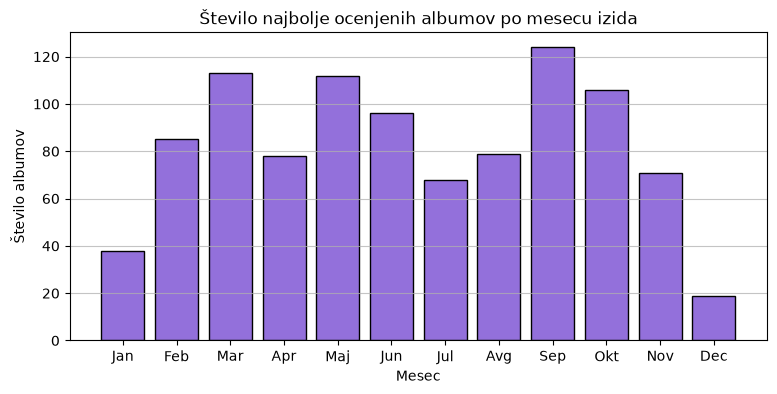

In [7]:
po_mesecu = df.dropna(subset=['mesec'])['mesec'].astype(int).value_counts().sort_index()
imena_mesecev = ['Jan', 'Feb', 'Mar', 'Apr', 'Maj', 'Jun',
                  'Jul', 'Avg', 'Sep', 'Okt', 'Nov', 'Dec']

plt.figure(figsize=(9, 4))
plt.bar([imena_mesecev[m - 1] for m in po_mesecu.index], po_mesecu.values,
        color='mediumpurple', edgecolor='black')
plt.title('Število najbolje ocenjenih albumov po mesecu izida')
plt.xlabel('Mesec')
plt.ylabel('Število albumov')
plt.grid(axis='y', alpha=0.75)
plt.show()

Predvsem me je zanimalom, kateri meseci prinašajo največ uspeha. Rezultati so me po eni strani presenetili, saj je decemberskih res malo, po drugi strani je bil pa vpad v decembru pričakovan, saj smo ljudje v prazničnih časih navajeni poslušati "klasične" skladbe za tisti čas, in ne posvečamo toliko pozornosti takratnim izdajam. Na samem vrhu pa lahko vidimo september, marec in maj. To, da je maj tako visoko se mi zdi kar smiselno, saj je tik pred začetkom poletja, ko ljudje še posebej radi poslušamo glasbo (recimo na dopustu).

## 7. Najpogostejši žanri

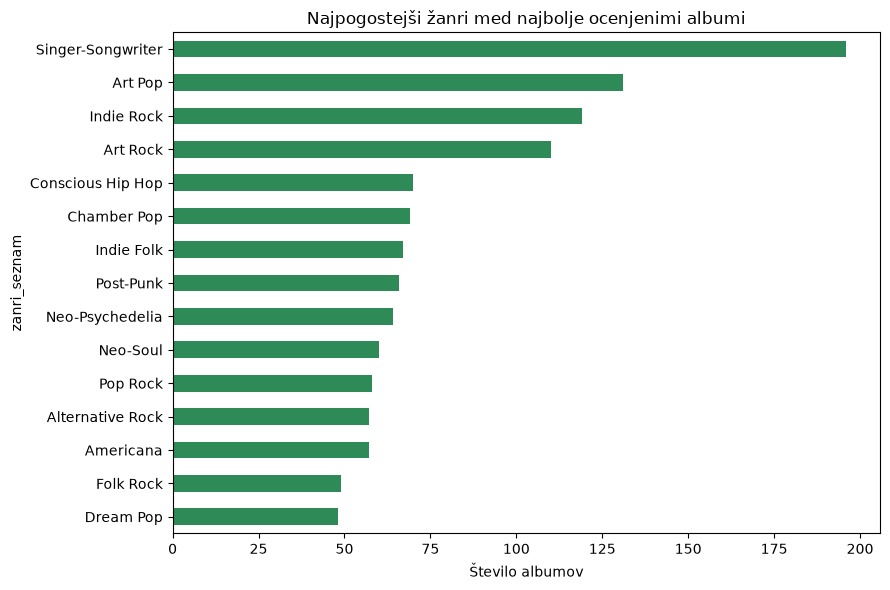

In [8]:
vsi_zanri = df.explode('zanri_seznam')['zanri_seznam']
vsi_zanri = vsi_zanri[vsi_zanri != '']
top_zanri = vsi_zanri.value_counts().head(15)

plt.figure(figsize=(9, 6))
top_zanri.plot(kind='barh', color='seagreen')
plt.xlabel('Število albumov')
plt.title('Najpogostejši žanri med najbolje ocenjenimi albumi')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Marsikdo se bi tudi vprašal kateri so najbolj priljubljeni žanri. Izraziti favorit je v tem primeru Singer-Songwriter, kar ni napaka, dejansko se tako reče žanru, angleška definicija le tega na naši strani, se glasi "With less emphasis on instrumental accompaniment, focuses on the writing, emotion and storytelling of the musician's lyrics. Rooted in Folk music.". To spet ni presenečenje, saj so tisti ta res dobri albumi ravno te, ki imajo neko sporočilo.

## 8. Razmerje med oceno in številom recenzij

Ali imajo bolj "priljubljeni" albumi (več recenzij) tudi višjo oceno?

Korelacija med oceno in številom recenzij: -0.461


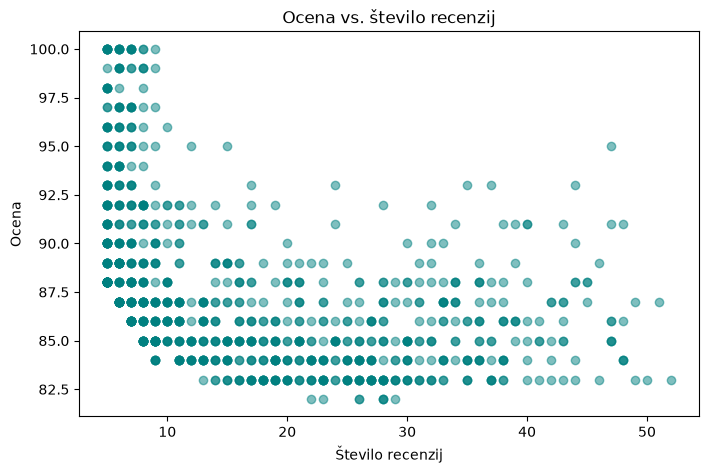

In [9]:
korelacija = df['ocena'].corr(df['st_recenzij'])
print(f'Korelacija med oceno in številom recenzij: {korelacija:.3f}')

plt.figure(figsize=(8, 5))
plt.scatter(df['st_recenzij'], df['ocena'], alpha=0.5, color='teal')
plt.xlabel('Število recenzij')
plt.ylabel('Ocena')
plt.title('Ocena vs. število recenzij')
plt.show()

Še ena pomembna opazka je, da se ocena albuma s številom recenzij načeloma zmanjšuje, ta pojav bi se lahko najlažje opiše z rekom: "vsake oči imajo svojega malarja", saj se pri večjem vzorcu poslušalcev lahko lažje najde nekdo, ki mu album ne bo tako pogodu kot ostalim.

## 9. Razmerje med letom izida in številom recenzij
Tukaj me je zanimalo, če leto izida vpliva na to koliko recenzij album ima, moja hipoteza je, da imajo novejši albumi (to tisočletje) večje število ocen, saj je glasba res dosegljiva povsod in je potemtakem tudi več kritikov.

,Izvajalec,Naslov,Leto,Ocena,Št. recenzij
944,Daft Punk,Random Access Memories,2013,83,52
208,Radiohead,A Moon Shaped Pool,2016,87,51
872,Tame Impala,Currents,2015,83,50
194,Bon Iver,"22, A Million",2016,87,49
882,Kanye West,Yeezus,2013,83,49
723,The National,Trouble Will Find Me,2013,84,48
44,Sufjan Stevens,Carrie & Lowell,2015,91,48
294,Aphex Twin,Syro,2014,86,48
749,The National,Sleep Well Beast,2017,84,48
743,Nick Cave & The Bad Seeds,Push the Sky Away,2013,84,48


Korelacija med letom izida in številom recenzij: 0.481


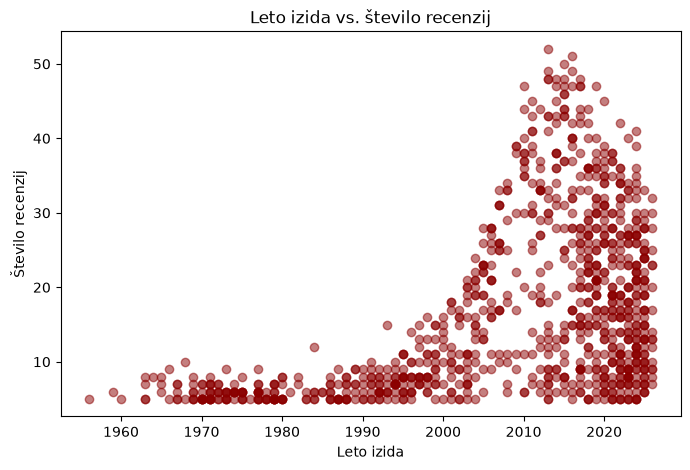

In [10]:
top10_recenzije = df.sort_values(by='st_recenzij', ascending=False).head(10)
display(top10_recenzije[['izvajalec', 'naslov', 'leto', 'ocena', 'st_recenzij']]
        .rename(columns=IMENA_STOLPCEV))

korelacija_leto = df['leto'].corr(df['st_recenzij'])
print(f'Korelacija med letom izida in številom recenzij: {korelacija_leto:.3f}')

plt.figure(figsize=(8, 5))
plt.scatter(df['leto'], df['st_recenzij'], alpha=0.5, color='darkred')
plt.xlabel('Leto izida')
plt.ylabel('Število recenzij')
plt.title('Leto izida vs. število recenzij')
plt.show()

Izkaže se, da je moja hipoteza pravilna, največje število recenzij imajo res albumi izdani med 2010 in 2020.

## 10. Dostopnost albumov

Na spletni strani sem opazil, da piše tudi kje vse ljudje lahko dostopamo do posameznih albumov.


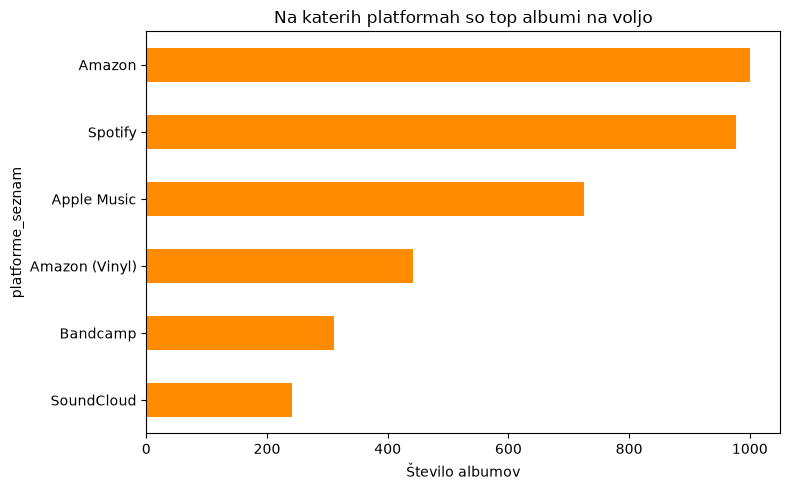

Albumov, ki niso na Spotifyju: 23 od 1000


In [11]:
vse_platforme = df.explode('platforme_seznam')['platforme_seznam']
vse_platforme = vse_platforme[vse_platforme != '']
stevilo_platform = vse_platforme.value_counts()

plt.figure(figsize=(8, 5))
stevilo_platform.plot(kind='barh', color='darkorange')
plt.xlabel('Število albumov')
plt.title('Na katerih platformah so top albumi na voljo')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

ni_na_spotify = df[~df['platforme_seznam'].apply(lambda p: 'Spotify' in p)]
print(f'Albumov, ki niso na Spotifyju: {len(ni_na_spotify)} od {len(df)}')

Za pojasnilo: Amazon/Vinyl sta nakupni povezavi (fizični/digitalni nakup), medtem ko so Spotify, Apple Music, SoundCloud in Bandcamp dejanske pretočne platforme za poslušanje. Videti je mogoče, da imata prevlado Amazon in pa Spotify, kjer tako rekoč lahko prideš do vsakega albuma, na dnu sta pa Soundcloud in Bandcamp, ki sta načeloma zastonj za uporabo, kar ima velik vpliv na vsebine, ki jih ponujata.

## 11. Zaključek

Analiza 1000 najbolje ocenjenih albumov vseh časov pokaže, da so ocene pričakovano zgoščene visoko, z največ albumi v razredu 85-89 točk. The Beatles z desetimi uvrstitvami izstopajo kot izvajalec z največ albumi na lestvici, največ albumov pa izvira iz 2020ih let - verjetno posledica lažje dostopnosti ustvarjanja glasbe danes. Zanimivo je razmerje med priljubljenostjo in kakovostjo: korelacija med oceno in številom recenzij je negativna, prav tako pa je opazna povezava med letom izida in številom recenzij - kar dodatno kaže, da širša prepoznavnost albuma še ne pomeni enotnejšega mnenja kritikov. Skoraj vsi albumi na lestvici so danes dostopni vsaj na eni pretočni platformi, kar kaže, da glasba priznanas strani kritikov s časom ni izgubila stika s poslušalci.